In [2]:
from manim import *

Vamos agora aplicar o que aprendemos até agora para fazer uma animação que poderíamos usar em sala de aula.

Nossa animação precisa representar o cálculo da área de um quadrado de lado $n$, mostrando um exemplo de cálculo para um quadrado de lado $n=2$. 

Provavelmente está pensando: "Isso não parece muito emocionante" e talvez realmente não seja, mas a ideia central desse exercício é entender o que nos realmente precisamos fazer para finalizar uma animação Manim, porque esse é um processo nada trivial.

Pode ser que você já tenha algo em mente para essa animação, e é quase instintivo querer começar a programar a animação logo de cara, mas acredite, essa **não é uma boa ideia**.

Existem diversas formas (ou até infinitas formas) de se fazer uma mesma animação, partir logo de cara para a programação é uma ideia ruim, pois sem uma visão muito clara de onde queremos chegar podemos passar um tempo desnecessariamente grande olhando para uma tela de código sem saber como prosseguir.

Por isso o primeiro passo de **toda** animação Manim é **planejamento**. Vamos começar nossa animação com um papel e uma caneta (ou um lápis) e desenhar e escrever o que queremos fazer.

Nesse caso sabemos que nosso objetivo principal é fazer uma animação para mostrar o desenvolvimento de uma conta para area de um quadrado. Vamos então fazer um desenho do que poderia ser um frame da nossa animação (não julguem a minha letra):

<img src="https://kallel181.github.io/Blog/static/images/uma_outra_introduo_ao_manim_2.png">

Aqui temos um exemplo de uma das telas da nossa animação, mais precisamente a tela final da animação. 

Temos uma boa ideia agora de quais elementos precisamos, a esquerda temos uma figura com alguns labels, um $A$ para representar a área de figura e $n$ para representar o lado da figura. Do lado direito temos o desenvolvimento da conta usando LaTeX.

Durante essa etapa de planejamento podemos ainda ver com mais clareza funcionalidades que precisamos, mas ainda não sabemos como elas funcionam, por exemplo, para essa animação precisamos que o quadrado tenha um preenchimento, porem não sabemos como fazer isso, além disso, precisamos mover o quadrado mais para a esquerda e as contas mais a direita, e ainda, colocar um título no topo do da animação.

Vamos então ver como podemos mover figuras na tela de forma mais individual.

# Movendo elementos e o sistema de coordenadas do Manim

Antes de falarmos sobre como mover figuras dentro do Manim precisamos investigar com mais detalhes o sistema de coordenadas do Manim, para isso, vamos usar um objeto muito útil, o `NumberPlane()`, vamos usar o seguinte código:

Manim Community v0.21.0

[09/15/26 20:22:25] WARNING  NumberPlaneExemplo has no play calls. Automatic video output has been   ]8;id=4469875;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py\manager.py]8;;\:]8;id=4469876;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py#219\219]8;;\
                             saved as a PNG instead.                                                               

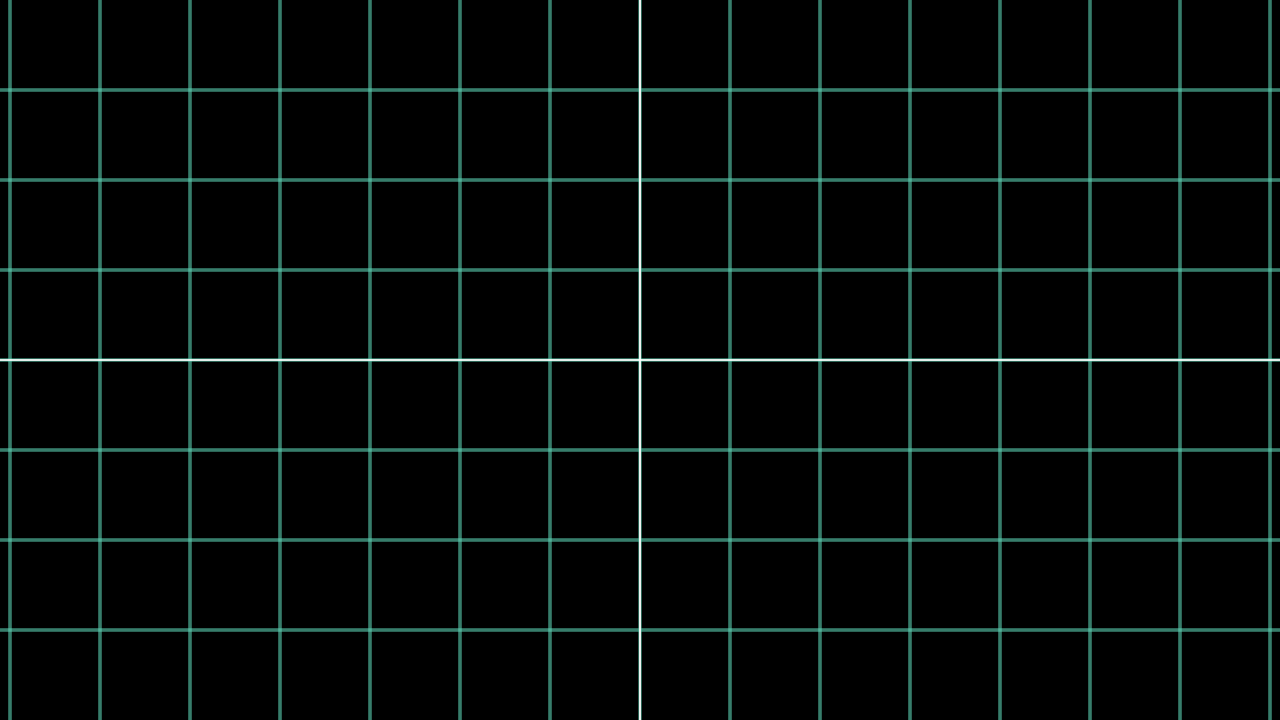

In [2]:
%%manim -qm -v WARNING NumberPlaneExemplo

from manim import *

class NumberPlaneExemplo(Scene):
    def construct(self):
        number_plane = NumberPlane(
            background_line_style={
                "stroke_color": TEAL,
                "stroke_width": 4,
                "stroke_opacity": 0.6
            }
        )
        self.add(number_plane)

Perceba que nessa "animação" não temos animação, só usamos o método `self.add()` para colocar nosso objeto na tela, dessa forma, quando renderizarmos esse projeto temos apenas uma imagem.

O `NumberPlane()` possui uma série de atributos para podermos configurar sua aparência, caso tenha curiosidade ver todos pode ver sua página na [documentação](https://docs.manim.community/en/stable/reference/manim.mobject.graphing.coordinate_systems.NumberPlane.html).

Podemos notar que o `NumberPlane()` desenha na tela um plano cartesiano onde as coordenadas $(0,0)$ estão no centro da imagem.

Vamos fazer uma adição a imagem, vamos usar o objeto `Dot()` que desenha um ponto na tela:

Manim Community v0.21.0

[09/15/26 20:22:41] WARNING  NumberPlaneDot has no play calls. Automatic video output has been saved ]8;id=4469887;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py\manager.py]8;;\:]8;id=4469888;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py#219\219]8;;\
                             as a PNG instead.                                                                     

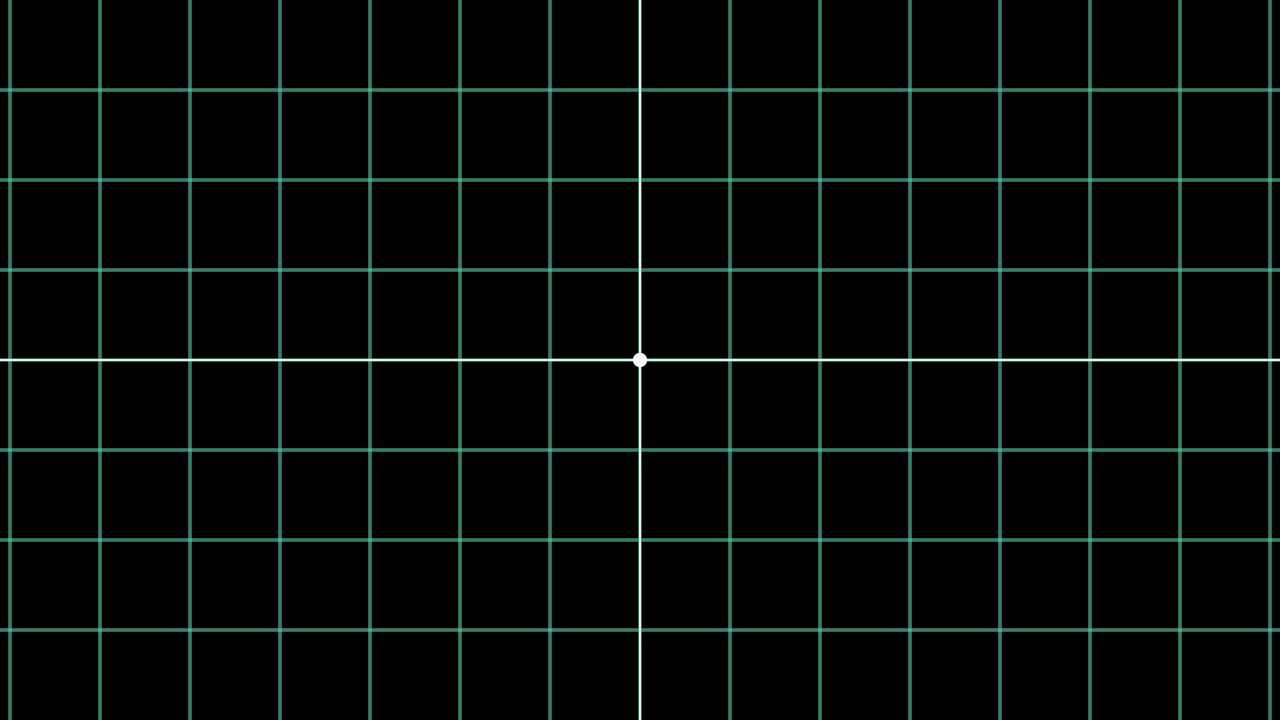

In [4]:
%%manim -qm -v WARNING NumberPlaneDot

from manim import *

class NumberPlaneDot(Scene):
    def construct(self):
        number_plane = NumberPlane(
            background_line_style={
                "stroke_color": TEAL,
                "stroke_width": 4,
                "stroke_opacity": 0.6
            }
        )
        self.add(number_plane)

        dot = Dot() #radius
        self.add(dot)

Podemos notar que sem alterar nada nos objeto eles são criados ao centro, mas como podemos movê-los?

Bem isso vai depender do objeto e do objetivo. Por exemplo, e se quisermos mudar o nosso ponto (ou `dot`) para as coordenadas $(2,2)$ ?

## Objetos com atributos de posição

No caso do objeto `Dot()` podemos passar um atributo `point` (podem checar isso na [documentação](https://docs.manim.community/en/stable/reference/manim.mobject.geometry.arc.Dot.html)):

Manim Community v0.21.0

[09/15/26 19:05:47] WARNING  NumberPlaneDotShift has no play calls. Automatic video output has been  ]8;id=11665367;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py\manager.py]8;;\:]8;id=11665368;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py#219\219]8;;\
                             saved as a PNG instead.                                                               

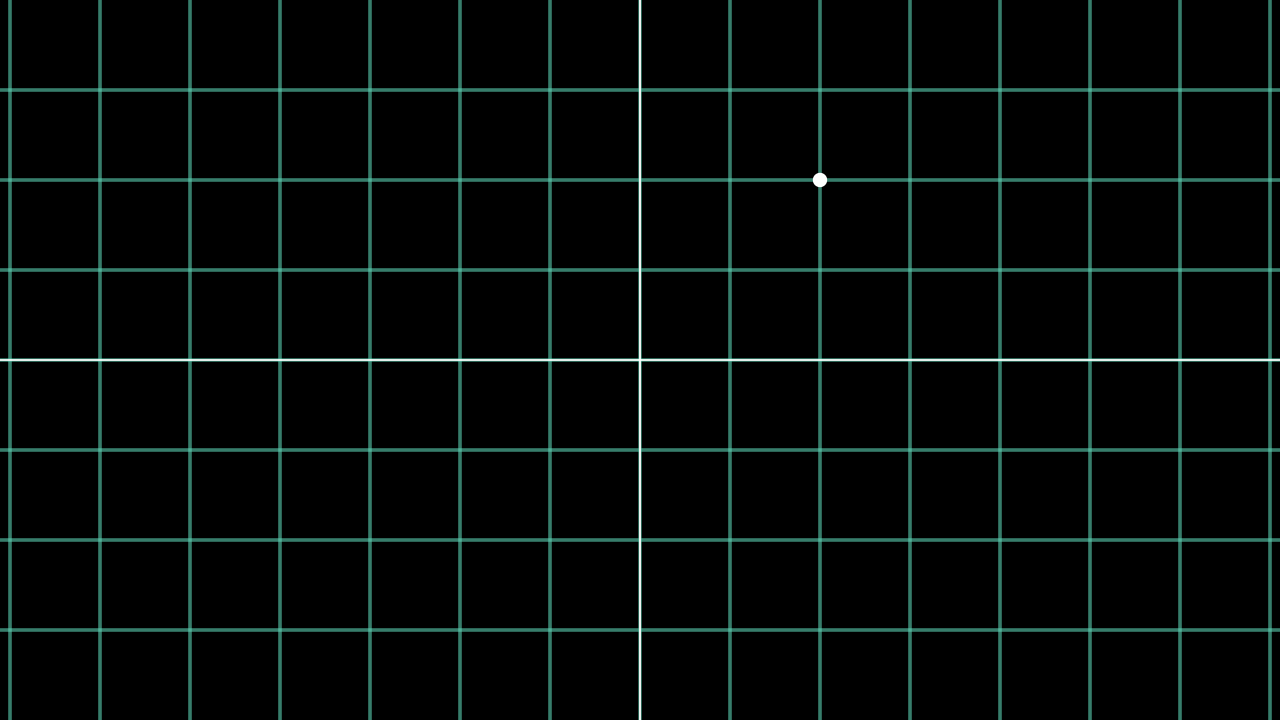

In [13]:
%%manim -qm -v WARNING NumberPlaneDotShift

from manim import *

class NumberPlaneDotShift(Scene):
    def construct(self):
        number_plane = NumberPlane(
            background_line_style={
                "stroke_color": TEAL,
                "stroke_width": 4,
                "stroke_opacity": 0.6
            }
        )
        self.add(number_plane)

        dot = Dot(point = 2*(RIGHT+UP))
        self.add(dot)

## Função `shift()`
Porem nem todos os objetos Manim possuem o atributo `point`, nesses casos podemos usar o método `shift()`.

Para demonstrar como o `shift()` funciona vamos usar um quadrado:

Manim Community v0.21.0

[09/15/26 20:24:01] WARNING  NumberPlaneShift has no play calls. Automatic video output has been     ]8;id=4469893;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py\manager.py]8;;\:]8;id=4469894;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py#219\219]8;;\
                             saved as a PNG instead.                                                               

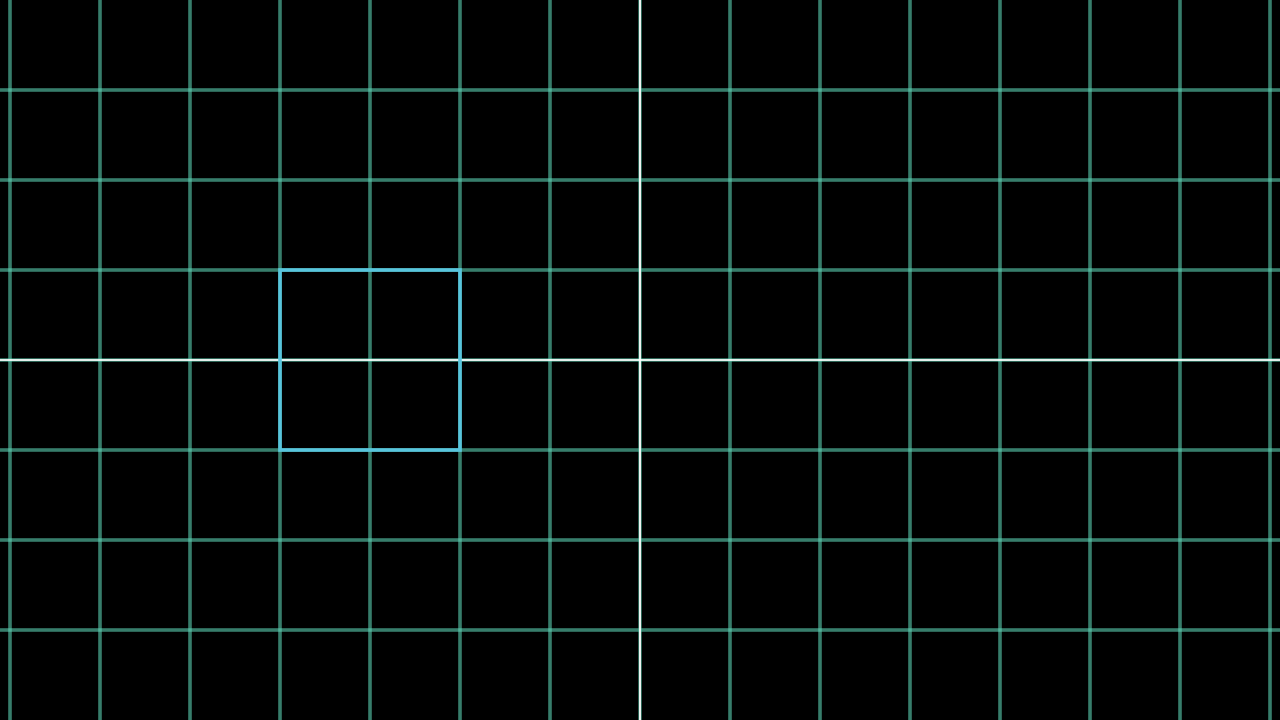

In [5]:
%%manim -qm -v WARNING NumberPlaneShift

from manim import *

class NumberPlaneShift(Scene):
    def construct(self):
        number_plane = NumberPlane(
            background_line_style={
                "stroke_color": TEAL,
                "stroke_width": 4,
                "stroke_opacity": 0.6
            }
        )
        self.add(number_plane)

        square = Square(color=BLUE)
        square.shift(LEFT*3) 

        self.add(square)

Para essa cena fizemos uma alteração no `stroke_opacity` do `NumberPlane()` para que o quadrado ficasse mais fácil de ver.

Podemos ver que o centro do quadrado foi deslocado 3 unidades para a esquerda. Algo importante de notarmos é que a função `shift()` move o objeto conforme o vetor que passamos para ela como parâmetro, nesse caso passamos o vetor $(-3,0)$, como o objeto estava no centro da tela, ou seja, no ponto $(0,0)$ ele foi movido para o ponto $(-3,0)$, porem se ele estivesse em $(2,2)$ para onde ele iria?

Com uma conta simples podemos prever que ele seria movido para $(-1,2)$, podemos testar isso com o seguinte código:

Manim Community v0.21.0

[09/15/26 19:11:39] WARNING  NumberPlaneShift2 has no play calls. Automatic video output has been    ]8;id=11665385;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py\manager.py]8;;\:]8;id=11665386;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py#219\219]8;;\
                             saved as a PNG instead.                                                               

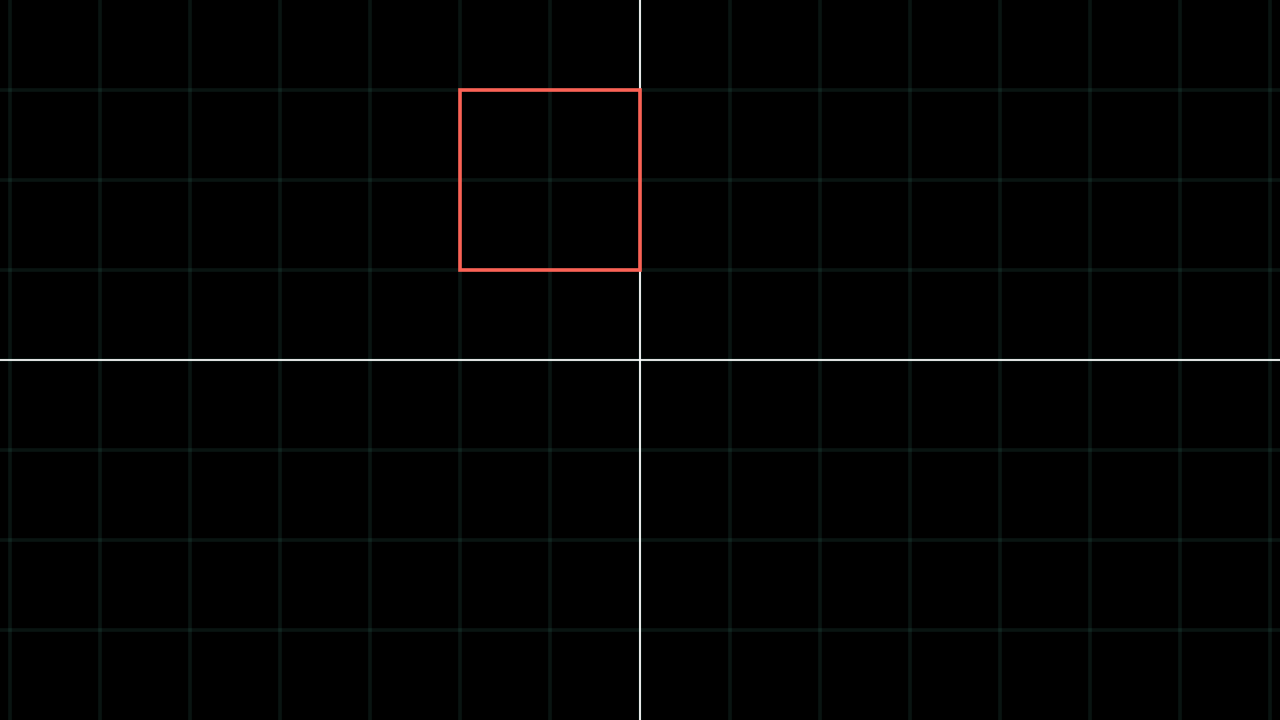

In [20]:
%%manim -qm -v WARNING NumberPlaneShift2

from manim import *

class NumberPlaneShift2(Scene):
    def construct(self):
        number_plane = NumberPlane(
            background_line_style={
                "stroke_color": TEAL,
                "stroke_width": 4,
                "stroke_opacity": 0.1
            }
        )
        self.add(number_plane)

        square = Square(color=RED)

        square.shift(RIGHT*2 + UP*2)
        square.shift(LEFT*3)

        self.add(square)

## Animando movimento
**Mas e se quisermos animar o objeto saindo de um ponto A para um ponto B?**

Nesse caso temos algumas formas diferentes de fazer isso, vamos ver quais são elas. Grande parte dessas formas usam algo chamado `animate`, essa funcionalidade faz com que qualquer método de um objeto possa ser animado. Mas o que isso quer fizer?

Vamos pegar um exemplo:

In [6]:
%%manim -qm -v WARNING WriteSquareExample

from manim import *

class WriteSquareExample(Scene):
    def construct(self):
        square = Square()
        square.set_color(BLUE)

        self.play(Write(square))

        self.wait()

Manim Community v0.21.0

Perceba que no código acima nós alteramos a cor do quadrado usando algo diferente, nesse caso o `square.set_color(BLUE)`, isso tem o mesmo efeito de colocarmos o atributo `color=blue` na criação do objeto, a diferença é que em `square.set_color(BLUE)` nós estamos usando a função `set_color()` do objeto `Square()` para mudar a cor dele.

Todas essas funções podem ser usadas junto do `animate` para criar animações, vamos ver algumas que mudam a posição do objeto:

## Animando movimento com `shift()`

A primeira que vamos ver é a função `shift()` que nós já usamos antes, já vimos que a função `shift()` faz o movimento de um objeto seguindo um vetor, vamos implementar o código de exemplo que apresentamos naquela seção, mas agora mostrando o movimento do quadrado:

In [5]:
%%manim -qm -v WARNING MoveSquareExample

from manim import *

class MoveSquareExample(Scene):
    def construct(self):
        number_plane = NumberPlane(
            background_line_style={
                "stroke_color": TEAL,
                "stroke_width": 4,
                "stroke_opacity": 0.1,
            }
        )
        self.add(number_plane)

        square = Square(color=RED)

        self.play(Write(square))

        self.wait()

        self.play(square.animate.shift(RIGHT * 2 + UP * 2))

        self.wait()

        self.play(square.animate.shift(LEFT * 3))

        self.wait()

Manim Community v0.21.0

## Animando Movimento com move_to()

Podemos alternativamente usar a função `move_to()`, diferente da função `shift()` a função `move_to()` recebe as coordenadas finais do objeto e não um vetor, dessa forma, pode ser mais fácil de controlar a posição do objeto:

In [9]:
%%manim -qm -v WARNING MoveSquareExample2

from manim import *

class MoveSquareExample2(Scene):
    def construct(self):
        number_plane = NumberPlane(
            background_line_style={
                "stroke_color": TEAL,
                "stroke_width": 4,
                "stroke_opacity": 0.1
            }
        )
        self.add(number_plane)

        square = Square(color=RED)

        self.play(Write(square))

        self.wait()

        #Ou (RIGHT*4 + UP*2)
        self.play(square.animate.move_to(np.array((4.0, 2.0, 0.0))))

        self.wait()

        #(-4,-2)
        self.play(square.animate.move_to(LEFT*4 + DOWN*2))

        self.wait()

Manim Community v0.21.0

# Alinhando objetos com arrange(), next_to() e to_edge()
Vamos agora ver como podemos alinhar objetos. Por alinhamento vamos entender a posição de objetos relativos a outra coisa, seja a outro(s) objeto(s) ou seja, em relação às bordas da tela.

## Função arrange()
Um método de alinhamento que já vimos é o método `arrange()` esse método é acessado dentro de grupos de objetos feitos usando `VGroup()`, vamos fazer um exemplo prático para entender seu funcionamento:

Manim Community v0.21.0

[09/15/26 20:31:40] WARNING  Equations has no play calls. Automatic video output has been saved as a ]8;id=4469899;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py\manager.py]8;;\:]8;id=4469900;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py#219\219]8;;\
                             PNG instead.                                                                          

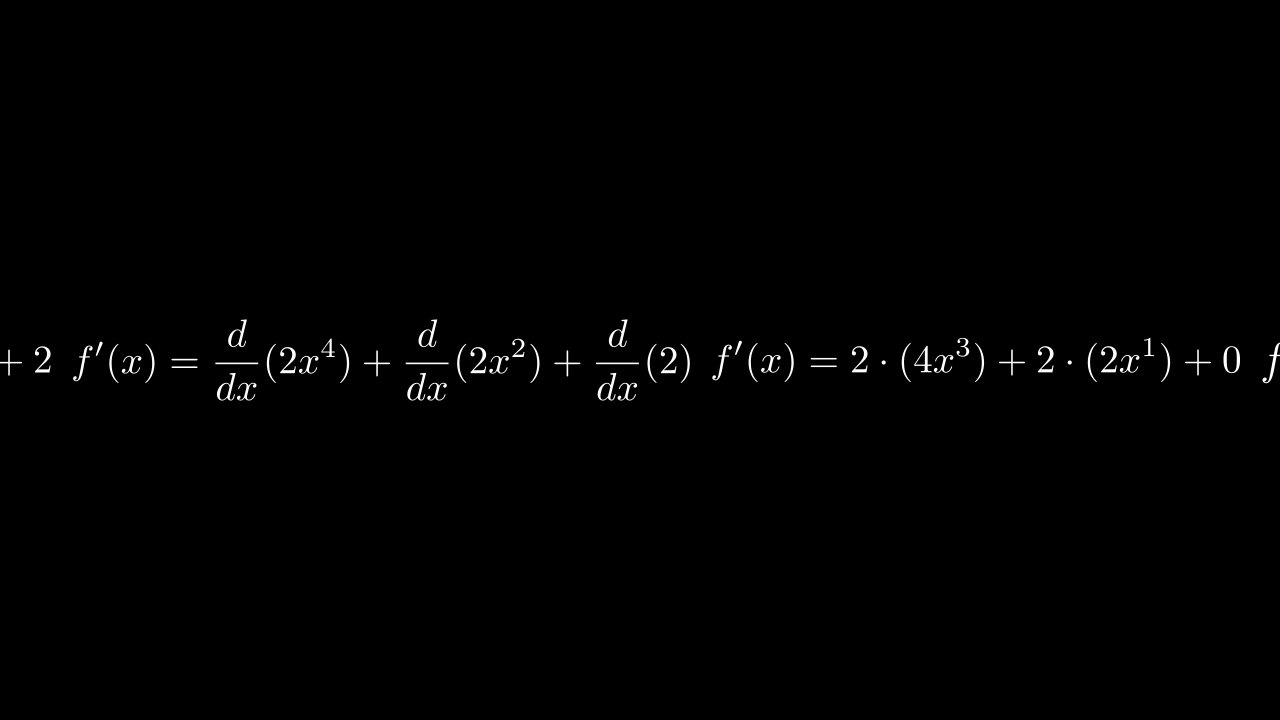

In [10]:
%%manim -qm -v WARNING Equations

from manim import *

class Equations(Scene):
    def construct(self):
        eq1 = MathTex(r"f(x) = 2x^4 + 2x^2 + 2", font_size=42)
        eq2 = MathTex(r"f'(x) = \frac{d}{dx}(2x^4) + \frac{d}{dx}(2x^2) + \frac{d}{dx}(2)", font_size=42)
        eq3 = MathTex(r"f'(x) = 2 \cdot (4x^3) + 2 \cdot (2x^1) + 0", font_size=42)
        eq4 = MathTex(r"f'(x) = 8x^3 + 4x", font_size=48)       

        grupo = VGroup(eq1,eq2,eq3,eq4).arrange()

        self.add(grupo)

Aqui temos o desenvolvimento de uma derivada, no caso para a função $f(x) = 2x^4 + 2x^2 + 2$:

$$f(x) = 2x^4 + 2x^2 + 2$$
$$f'(x) = \frac{d}{dx}(2x^4) + \frac{d}{dx}(2x^2) + \frac{d}{dx}(2)$$
$$f'(x) = 2 \cdot (4x^3) + 2 \cdot (2x^1) + 0$$
$$f'(x) = 8x^3 + 4x$$

Podemos ver que a imagem gerada não está certa, por padrão o método `arrange()` sempre vai dispor os elementos um à direita do outro, porem não é isso que queremos, precisamos que um esteja abaixo do outro, para isso podemos usar o parâmetro `direction=DOWN`:

Manim Community v0.21.0

[09/15/26 20:31:58] WARNING  Equations2 has no play calls. Automatic video output has been saved as  ]8;id=4469905;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py\manager.py]8;;\:]8;id=4469906;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py#219\219]8;;\
                             a PNG instead.                                                                        

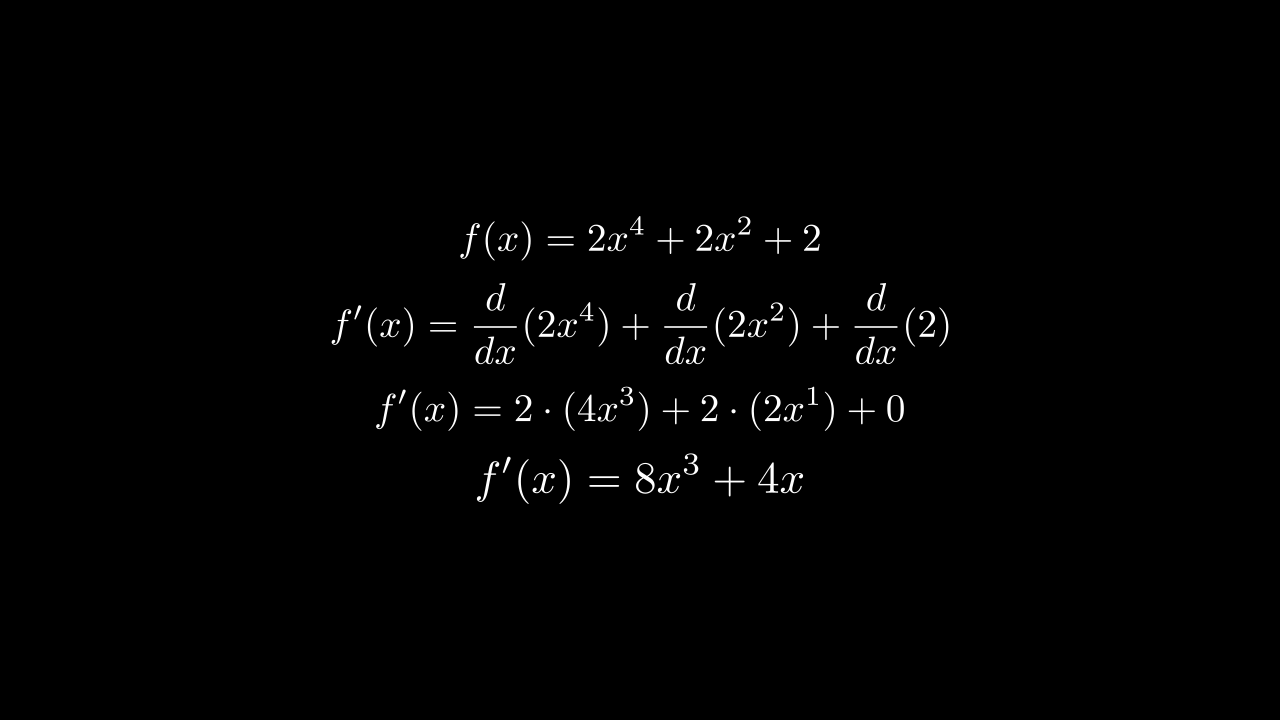

In [11]:
%%manim -qm -v WARNING Equations2

from manim import *

class Equations2(Scene):
    def construct(self):
        eq1 = MathTex(r"f(x) = 2x^4 + 2x^2 + 2", font_size=42)
        eq2 = MathTex(r"f'(x) = \frac{d}{dx}(2x^4) + \frac{d}{dx}(2x^2) + \frac{d}{dx}(2)", font_size=42)
        eq3 = MathTex(r"f'(x) = 2 \cdot (4x^3) + 2 \cdot (2x^1) + 0", font_size=42)
        eq4 = MathTex(r"f'(x) = 8x^3 + 4x", font_size=48)       

        grupo = VGroup(eq1,eq2,eq3,eq4).arrange(direction=DOWN)

        self.add(grupo)

Esse é justamente o resultado que queríamos. Podemos ver a [documentação](https://docs.manim.community/en/stable/reference/manim.mobject.mobject.Mobject.html#manim.mobject.mobject.Mobject.arrange) do `arrange()` para obter mais detalhes, por exemplo, podemos usar o parâmetro, `buff` para aumentar a distância entre os objetos do grupo.

Manim Community v0.21.0

[09/15/26 20:32:20] WARNING  Equations3 has no play calls. Automatic video output has been saved as  ]8;id=4469911;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py\manager.py]8;;\:]8;id=4469912;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py#219\219]8;;\
                             a PNG instead.                                                                        

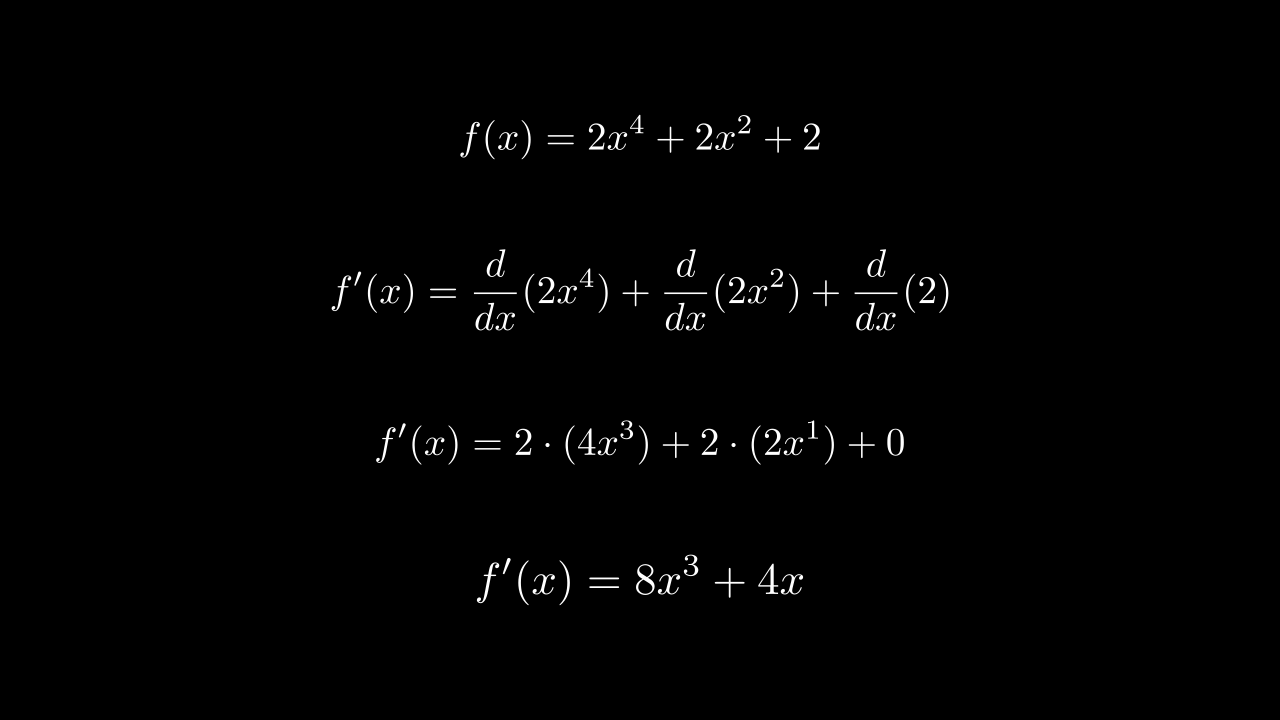

In [12]:
%%manim -qm -v WARNING Equations3

from manim import *

class Equations3(Scene):
    def construct(self):
        eq1 = MathTex(r"f(x) = 2x^4 + 2x^2 + 2", font_size=42)
        eq2 = MathTex(r"f'(x) = \frac{d}{dx}(2x^4) + \frac{d}{dx}(2x^2) + \frac{d}{dx}(2)", font_size=42)
        eq3 = MathTex(r"f'(x) = 2 \cdot (4x^3) + 2 \cdot (2x^1) + 0", font_size=42)
        eq4 = MathTex(r"f'(x) = 8x^3 + 4x", font_size=48)       

        grupo = VGroup(eq1,eq2,eq3,eq4).arrange(direction=DOWN,buff=1.0)

        self.add(grupo)

## Função next_to()
A função `next_to()` é usada para posicionar elementos próximos de outros elementos, por exemplo, para nossa animação do cálculo da área de um quadrado precisamos como um $n$ ao lado do quadrado e outro logo acima dele.

Vamos analisar o funcionamento do `next_to()` com o seguinte código:

Manim Community v0.21.0

[09/15/26 20:34:16] WARNING  Proximo1 has no play calls. Automatic video output has been saved as a  ]8;id=4469917;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py\manager.py]8;;\:]8;id=4469918;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py#219\219]8;;\
                             PNG instead.                                                                          

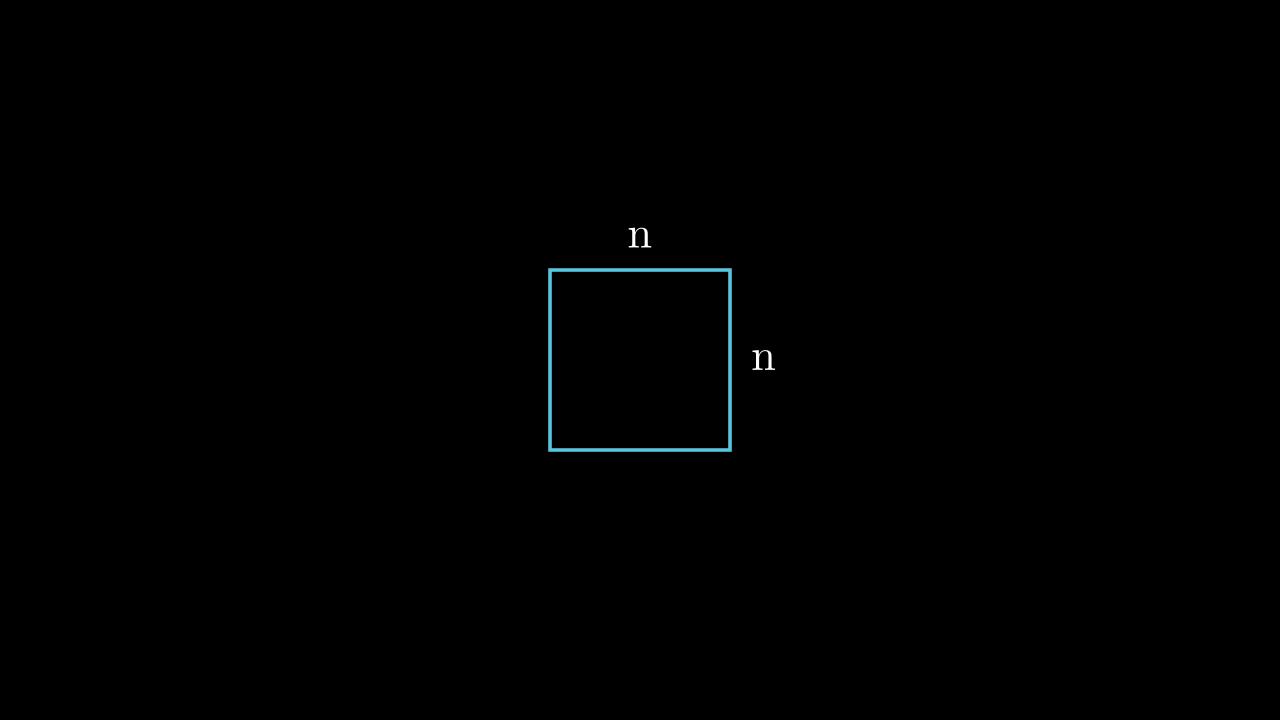

In [13]:
%%manim -qm -v WARNING Proximo1

from manim import *

class Proximo1(Scene):
    def construct(self):
        quadrado = Square(color=BLUE)

        latex_n1 = Tex(r"n")
        latex_n2 = Tex(r"n")

        latex_n1.next_to(quadrado,RIGHT)
        latex_n2.next_to(quadrado, UP)

        grupo = VGroup(quadrado, latex_n1, latex_n2)

        self.add(grupo)

Se observamos a [documentação](https://docs.manim.community/en/stable/reference/manim.mobject.mobject.Mobject.html#manim.mobject.mobject.Mobject.next_to) da função `next_to()` temos que definir algum outro objeto, assim, temos que o objeto a esquerda, que no nosso exemplo são `latex_n1` e `latex_n2` devem ficar próximos do objeto `quadrado`, porem `latex_n1` precisa ficar a direita (`RIGHT`) e `latex_n2` precisa ficar acima (`UP`).

Assim como no `arrange()` também podemos definir uma distância extra entre os elementos usando o parâmetro `buff`.

## Função `to_edge()`
A função `to_edge()` tem um funcionamento parecido com da função `next_to()`, porem a função `to_edge()` posiciona o elemento para uma borda da tela, vamos ver um exemplo:

Manim Community v0.21.0

[09/19/26 17:07:33] WARNING  Borda has no play calls. Automatic video output has been saved as a PNG ]8;id=11420424;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py\manager.py]8;;\:]8;id=11420425;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py#219\219]8;;\
                             instead.                                                                              

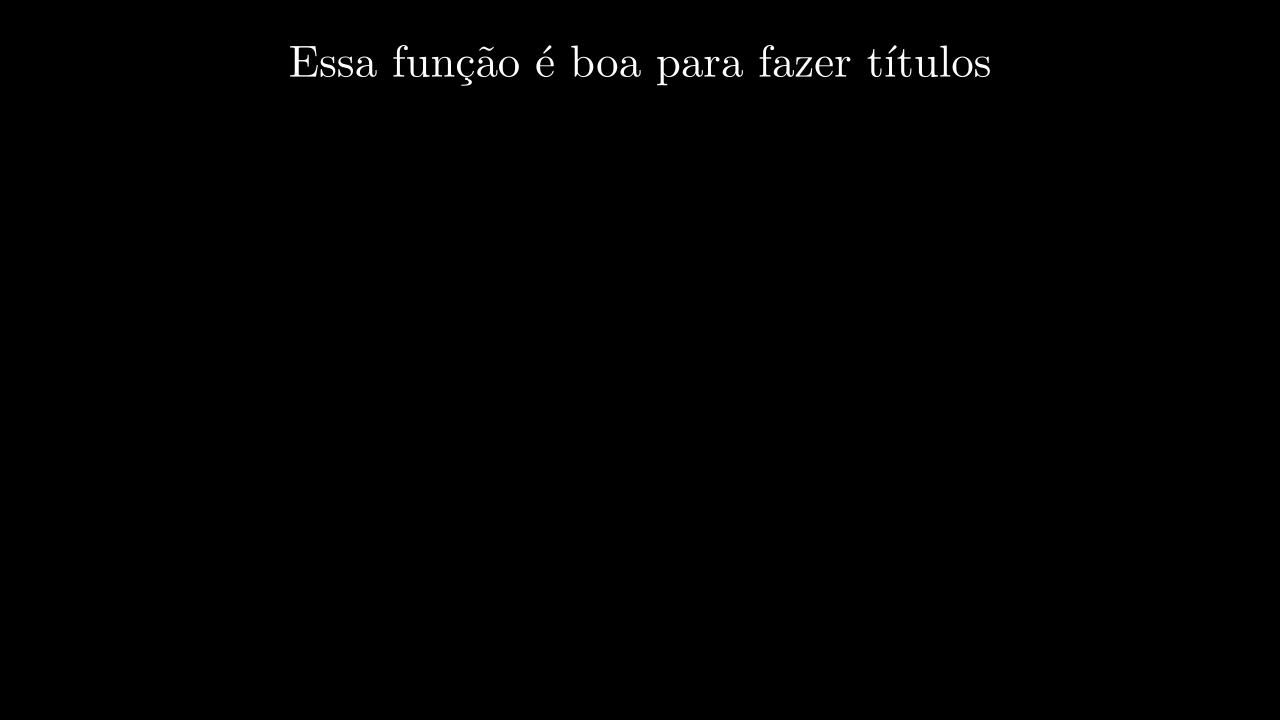

In [3]:
%%manim -qm -v WARNING Borda

from manim import *

class Borda(Scene):
    def construct(self):
        texto = Tex(r"Essa função é boa para fazer títulos")

        texto.to_edge(UP)

        self.add(texto)

Na [documentação](https://docs.manim.community/en/stable/reference/manim.mobject.mobject.Mobject.html#manim.mobject.mobject.Mobject.to_edge) da função podemos ver que tudo que ela precisa para ajustar a posição do objeto é um vetor que indique a direção, e assim como as outras funções também podemos definir um `buff`.

## Função `get_center()`
A função `get_center()` nos retorna o centro de um objeto, o que pode ser particularmente útil quando precisamos mudar a posição de outro objeto para ser o centro de um segundo objeto, vamos ver um exemplo de aplicação:

Manim Community v0.21.0

[09/15/26 20:35:02] WARNING  Center has no play calls. Automatic video output has been saved as a    ]8;id=4469923;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py\manager.py]8;;\:]8;id=4469924;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py#219\219]8;;\
                             PNG instead.                                                                          

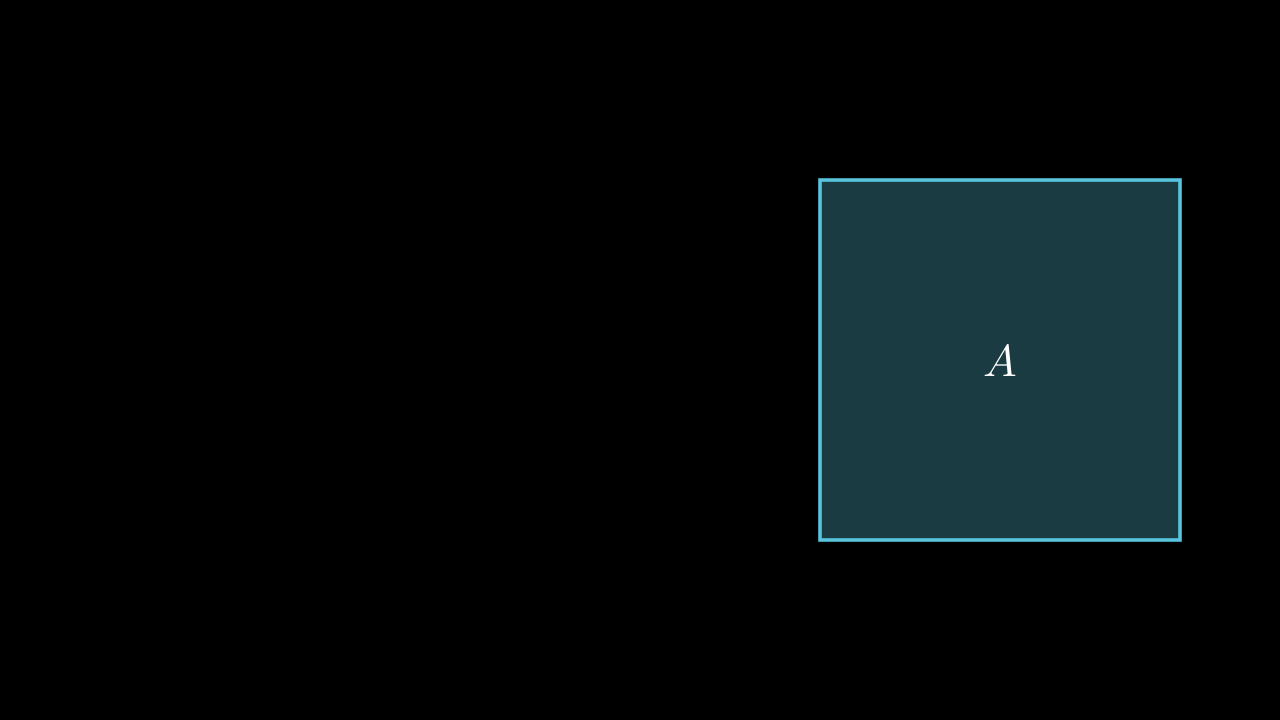

In [14]:
%%manim -qm -v WARNING Center

from manim import *

class Center(Scene):
    def construct(self):
        texto = MathTex(r"A")

        quadrado = Square(color=BLUE,side_length=4,fill_opacity=0.3)

        quadrado.move_to(RIGHT*4)

        texto.move_to(quadrado.get_center())
        texto.set_z_index(1)        

        grupo = VGroup(texto, quadrado)

        self.add(grupo)

Perceba que nosso objetivo era deixar o $A$ no centro do quadrado, porem nos deslocamos ele para a direita, dessa forma, precisamos da nova posição do quadrado para que o $A$ fique ao centro, a forma que fizemos faz uso da função `get_center()`, porem, poderíamos mover alternativamente o $A$ para a direita na mesma quantidade que movemos o quadrado, mas usar a posição absoluta do objeto é muito menos suscetível a erros.

Podemos ver mais detalhes da função `get_center()` na [documentação](https://docs.manim.community/en/stable/reference/manim.mobject.mobject.Mobject.html#manim.mobject.mobject.Mobject.get_center), mas seu funcionamento é simples, ele não recebe nenhum parâmetro e retorna o centro (no caso as coordenadas) do objeto.

Além disso, para esse exemplo fizemos o uso da função `set_z_index()`, isso porque estamos colocando dos objetos um sobre o outro, por isso precisamos definir quem está na frente.

<img src="https://kallel181.github.io/Blog/static/images/uma_outra_introduo_ao_manim_16.png">

# Alterando Objetos Visualmente
Agora sabemos o básico sobre posicionamento de objetos na tela, mas como podemos alterar o visual desses objetos? 

Essa não é uma pergunta difícil, nós já estamos até agora alterando o visual de objetos, sabemos que existem atributos nos objetos que, quando alterados, mudam o visual dos objetos, mas as perguntas que ainda ficam são: como eu descubro o nome desses atributos? Como descubro o que colocar em cada um deles? E como eu descubro quais são os atributos?

Para isso podemos observar a [documentação](https://docs.manim.community/en/stable/reference/manim.mobject.geometry.polygram.Square.html), mais especificamente precisamos olhar a documentação do objeto `Square()`.

Na página podemos encontrar informações uteis do objeto, exemplos de uso e o que estamos procurando, os atributos:

<img src="https://kallel181.github.io/Blog/static/images/uma_outra_introduo_ao_manim_17.png">

Nesse caso, para nossa animação nos interessa os atributos: `color`, `side_length`, `fill_color` e `fill_opacity`.

Algo que pode estar te incomodando é que o `fill_opacity` não aparece na lista, e realmente isso é um problema, principalmente para iniciantes, mas isso é algo comum, isso acontece porque o objeto `Square()` herda propriedade de outro objeto, dessa forma essa propriedade só pode ser vista nesse objeto.

> **Por que `fill_opacity` funciona no `Square()`?**
> O parâmetro é repassado via `**kwargs` através da **Herança de Classes (POO)**.
> 
>`Square` $\rightarrow$ `Rectangle` $\rightarrow$ `Polygon` $\rightarrow$ `Polygram` $\rightarrow$ **`VMobject`** $\rightarrow$ **`Mobject`**
>
>Ele é originalmente definido na classe base **`VMobject`**, que gerencia o preenchimento e os atributos vetoriais no Manim.

Com isso podemos testar esses atributos para ver como eles alteram a objeto final:

Manim Community v0.21.0

[09/19/26 17:15:48] WARNING  SquareVisualChange has no play calls. Automatic video output has been   ]8;id=11420442;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py\manager.py]8;;\:]8;id=11420443;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py#219\219]8;;\
                             saved as a PNG instead.                                                               

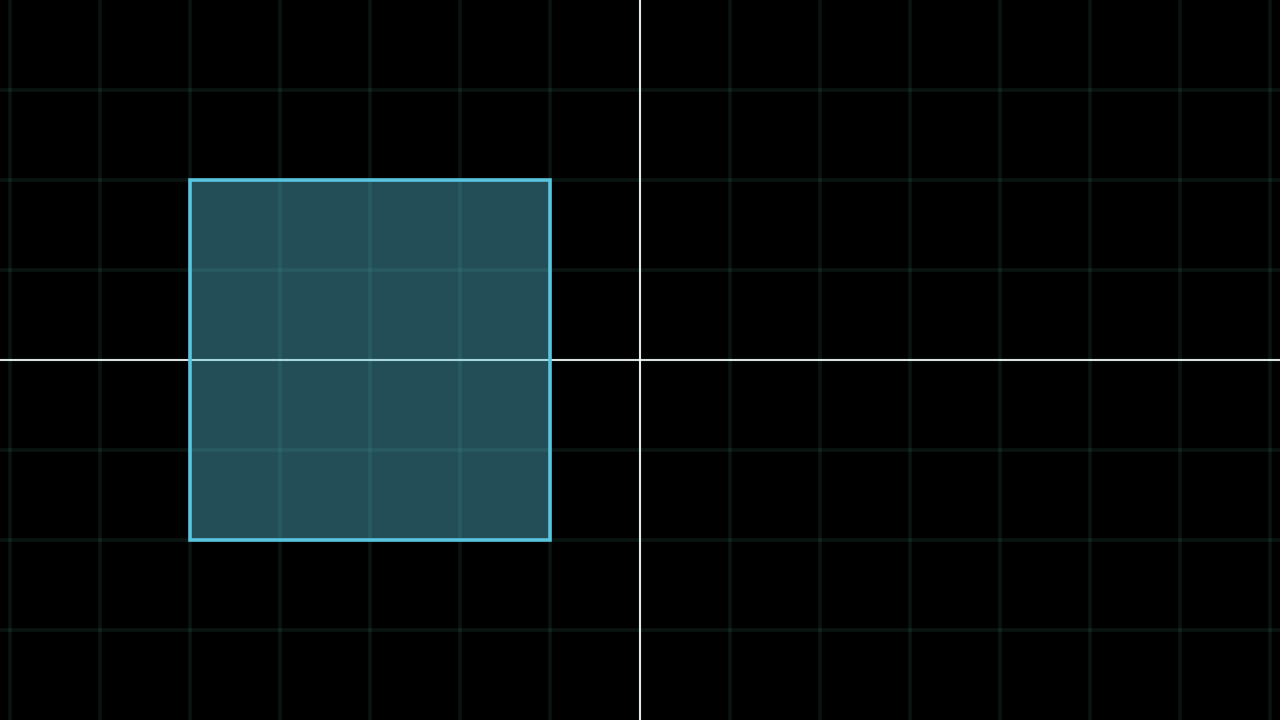

In [8]:
%%manim -qm -v WARNING SquareVisualChange

from manim import *  

class SquareVisualChange(Scene):
    def construct(self):
        number_plane = NumberPlane(
            background_line_style={
                "stroke_color": TEAL,
                "stroke_width": 4,
                "stroke_opacity": 0.1
            }
        )

        self.add(number_plane)

        square = Square(
            color=BLUE,
            fill_color=BLUE,
            side_length=4,
            fill_opacity=0.4
        )

        square.shift(LEFT * 3)  
        self.add(square)

Alternativamente podemos usar a função `scale()` para alterar o tamanho de objetos, na [documentação](https://docs.manim.community/en/stable/reference/manim.mobject.mobject.Mobject.html#manim.mobject.mobject.Mobject.scale) da função podemos ver um exemplo.

**Agora que já sabemos todas as funcionalidades que precisamos vamos tentar implementar nosso projeto inicial.**

Manim Community v0.21.0

[09/19/26 17:16:12] WARNING  Projeto2 has no play calls. Automatic video output has been saved as a  ]8;id=11420448;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py\manager.py]8;;\:]8;id=11420449;file:///opt/venv/lib/python3.14/site-packages/manim/manager.py#219\219]8;;\
                             PNG instead.                                                                          

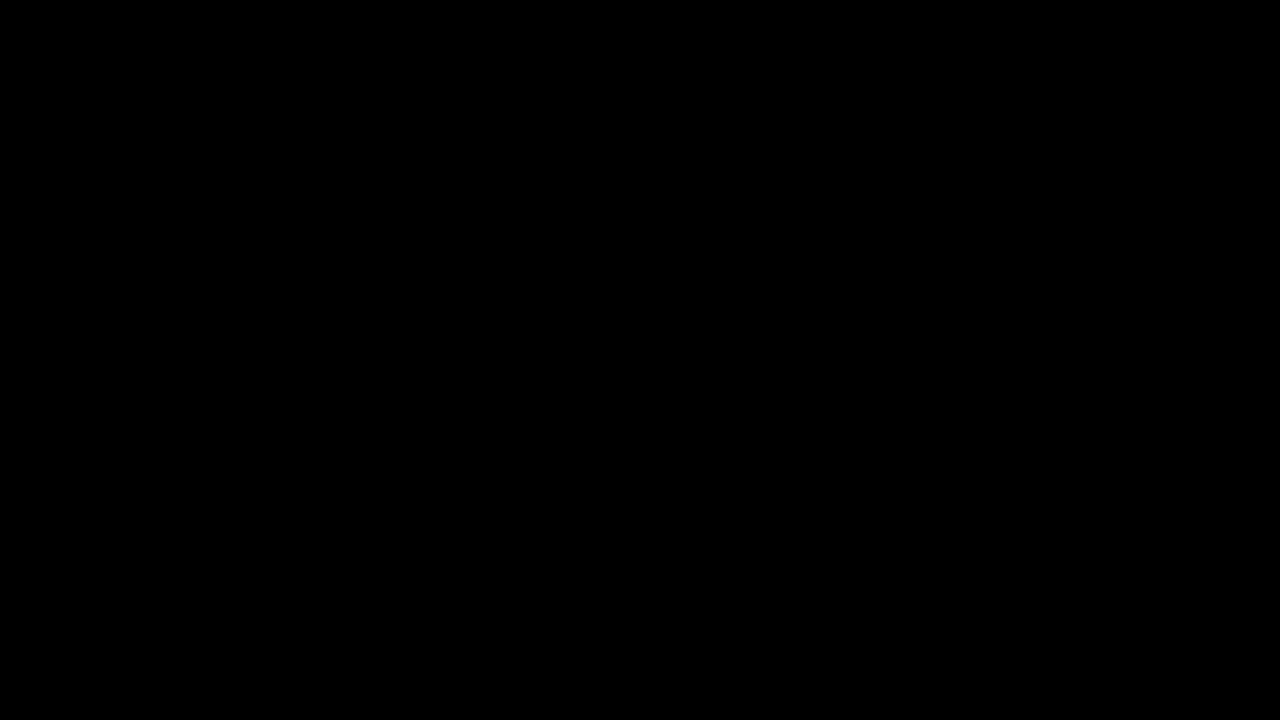

In [9]:
%%manim -qm -v WARNING Projeto2

from manim import *

class Projeto2(Scene):
    def construct(self):
        pass
        #Escreva aqui sua implementação do projéto!!



